# Online Retail Business Intelligence Analysis

**Dataset:** Online Retail Dataset (UCI / Kaggle)

**Objective:**
Analyze sales transactions to uncover business insights, identify customer purchasing behavior, perform RFM segmentation, and prepare data for SQL and Power BI analysis.

---

## Notebook Structure

1. Import Libraries
2. Load Dataset
3. Initial Exploratory Data Analysis
4. Data Cleaning
5. Feature Engineering
6. Business Exploratory Data Analysis
7. Business Insights
8. RFM Customer Segmentation
9. Export Files

# Executive Summary

This project analyzes the Online Retail dataset to identify sales trends, customer purchasing behavior, and business performance.

The analysis includes:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- KPI calculation
- Customer segmentation using RFM analysis
- Data export for SQL and Power BI

The goal is to transform raw transactional data into meaningful business insights that support data-driven decision-making.

##  Import Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']     = 120
plt.rcParams['figure.figsize'] = (12, 5)


##  Load the Data

In [6]:
df = pd.read_csv("../DataSet/online_retail.csv")
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Initial Exploratory Data Analysis (Data Understanding)

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [8]:
df.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 5268


In [11]:
print("="*40)
print("Number of Rows :", len(df))
print("Number of Columns :", len(df.columns))
print("Unique Products :", df["StockCode"].nunique())
print("Unique Customers :", df["CustomerID"].nunique())
print("Countries :", df["Country"].nunique())
print("="*40)

Number of Rows : 541909
Number of Columns : 8
Unique Products : 4070
Unique Customers : 4372
Countries : 38


# Data Cleaning

The raw dataset contains duplicate records, cancelled invoices, invalid quantities, and invalid prices. These issues must be removed before performing any business analysis.

The following cleaning steps are applied:

1. Remove duplicate rows.
2. Remove cancelled invoices.
3. Remove negative or zero quantities.
4. Remove zero or negative prices.
5. Create new features for analysis.


In [12]:
df_clean = df.copy()

print("Original Shape:", df.shape)
print("Working Copy Shape:", df_clean.shape)

Original Shape: (541909, 8)
Working Copy Shape: (541909, 8)


In [13]:
# ==========================================
# Remove Duplicate Rows
# ==========================================

duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)

df_clean.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df_clean.shape)

Duplicate Rows: 5268
Shape After Removing Duplicates: (536641, 8)


In [14]:
# ==========================================
# Remove Cancelled Invoices
# ==========================================

cancelled = df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Cancelled Invoices:", cancelled)

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

print("Shape After Removing Cancellations:", df_clean.shape)

Cancelled Invoices: 9251
Shape After Removing Cancellations: (527390, 8)


In [15]:
# ==========================================
# Remove Invalid Quantities
# ==========================================

negative_qty = (df_clean["Quantity"] <= 0).sum()

print("Invalid Quantity Rows:", negative_qty)

df_clean = df_clean[df_clean["Quantity"] > 0]

print("Shape After Quantity Cleaning:", df_clean.shape)

Invalid Quantity Rows: 1336
Shape After Quantity Cleaning: (526054, 8)


In [16]:
# ==========================================
# Remove Invalid Prices
# ==========================================

invalid_price = (df_clean["UnitPrice"] <= 0).sum()

print("Invalid Price Rows:", invalid_price)

df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("Shape After Price Cleaning:", df_clean.shape)

Invalid Price Rows: 1176
Shape After Price Cleaning: (524878, 8)


In [17]:
print("="*50)
print("Final Clean Dataset Shape")
print(df_clean.shape)
print("="*50)

Final Clean Dataset Shape
(524878, 8)


# Feature Engineering

In [18]:
df_clean["TotalSales"] = (
    df_clean["Quantity"] *
    df_clean["UnitPrice"]
)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [19]:
# ==========================================
# Convert InvoiceDate
# ==========================================

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [20]:
# ==========================================
# Time Features
# ==========================================

df_clean["Year"] = df_clean["InvoiceDate"].dt.year

df_clean["Month"] = df_clean["InvoiceDate"].dt.month

df_clean["MonthName"] = df_clean["InvoiceDate"].dt.strftime("%b")

df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()

df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

In [21]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,Dec,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,Dec,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,Wednesday,8


In [22]:
print("=" * 60)
print("Final Dataset Information")
print("=" * 60)

print(f"Rows: {len(df_clean):,}")
print(f"Columns: {len(df_clean.columns)}")
print(f"Countries: {df_clean['Country'].nunique()}")
print(f"Products: {df_clean['StockCode'].nunique()}")
print(f"Customers: {df_clean['CustomerID'].nunique()}")

print("=" * 60)

Final Dataset Information
Rows: 524,878
Columns: 14
Countries: 38
Products: 3922
Customers: 4338


# Business Exploratory Data Analysis (EDA)

After cleaning and preparing the dataset, this section explores key business metrics and sales patterns.

The analysis focuses on:

- Revenue KPIs
- Monthly sales trend
- Product performance
- Country performance
- Sales by day of week

In [23]:
# ==========================================
# Business KPIs
# ==========================================

total_revenue = df_clean["TotalSales"].sum()

total_orders = df_clean["InvoiceNo"].nunique()

total_customers = df_clean["CustomerID"].nunique()

unique_products = df_clean["StockCode"].nunique()

countries = df_clean["Country"].nunique()

average_order_value = (
    df_clean.groupby("InvoiceNo")["TotalSales"]
    .sum()
    .mean()
)

In [24]:
print("=" * 50)
print("BUSINESS KPIs")
print("=" * 50)

print(f"Total Revenue      : £{total_revenue:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Unique Products    : {unique_products:,}")
print(f"Countries Served   : {countries}")
print(f"Average Order Value: £{average_order_value:,.2f}")

BUSINESS KPIs
Total Revenue      : £10,642,110.80
Total Orders       : 19,960
Total Customers    : 4,338
Unique Products    : 3,922
Countries Served   : 38
Average Order Value: £533.17


In [25]:
# ==========================================
# Monthly Revenue
# ==========================================

monthly_sales = (
    df_clean.groupby(["Year", "Month"])["TotalSales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,TotalSales
0,2010,12,821452.730
1,2011,1,689811.610
2,2011,2,522545.560
3,2011,3,716215.260
4,2011,4,536968.491


In [26]:
monthly_sales["YearMonth"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

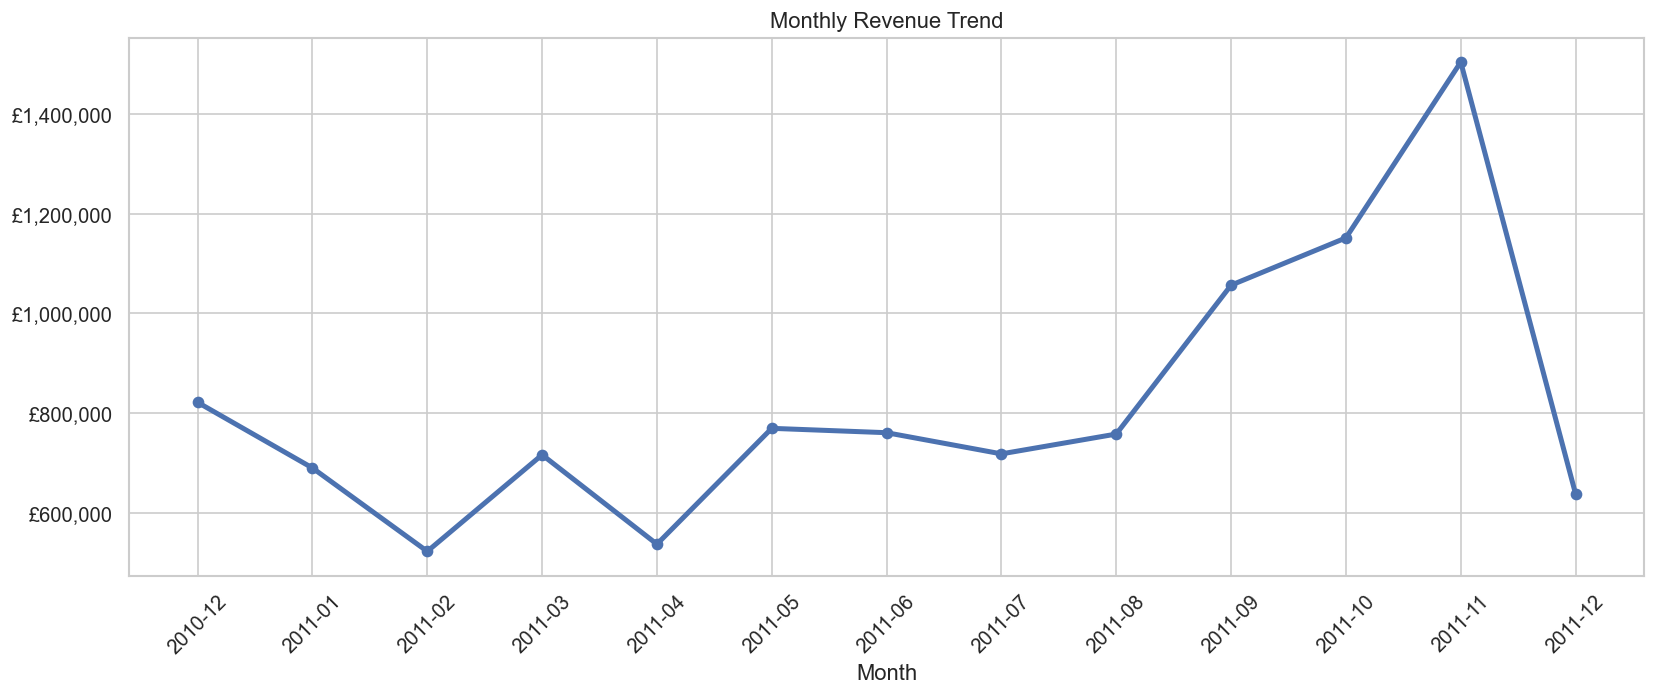

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalSales"],
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

import matplotlib.ticker as mtick

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

plt.tight_layout()

plt.show()

In [28]:
peak_month = monthly_sales.loc[
    monthly_sales["TotalSales"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["TotalSales"].idxmin()
]

print(f"Highest Revenue Month : {peak_month['YearMonth']}")
print(f"Revenue               : £{peak_month['TotalSales']:,.2f}")

print()

print(f"Lowest Revenue Month  : {lowest_month['YearMonth']}")
print(f"Revenue               : £{lowest_month['TotalSales']:,.2f}")

Highest Revenue Month : 2011-11
Revenue               : £1,503,866.78

Lowest Revenue Month  : 2011-02
Revenue               : £522,545.56


In [29]:
# ==========================================
# Top 10 Products by Revenue
# ==========================================

non_product_items = ["DOTCOM POSTAGE", "POSTAGE", "Manual"]

top_products = (
    df_clean[~df_clean["Description"].isin(non_product_items)]
    .groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

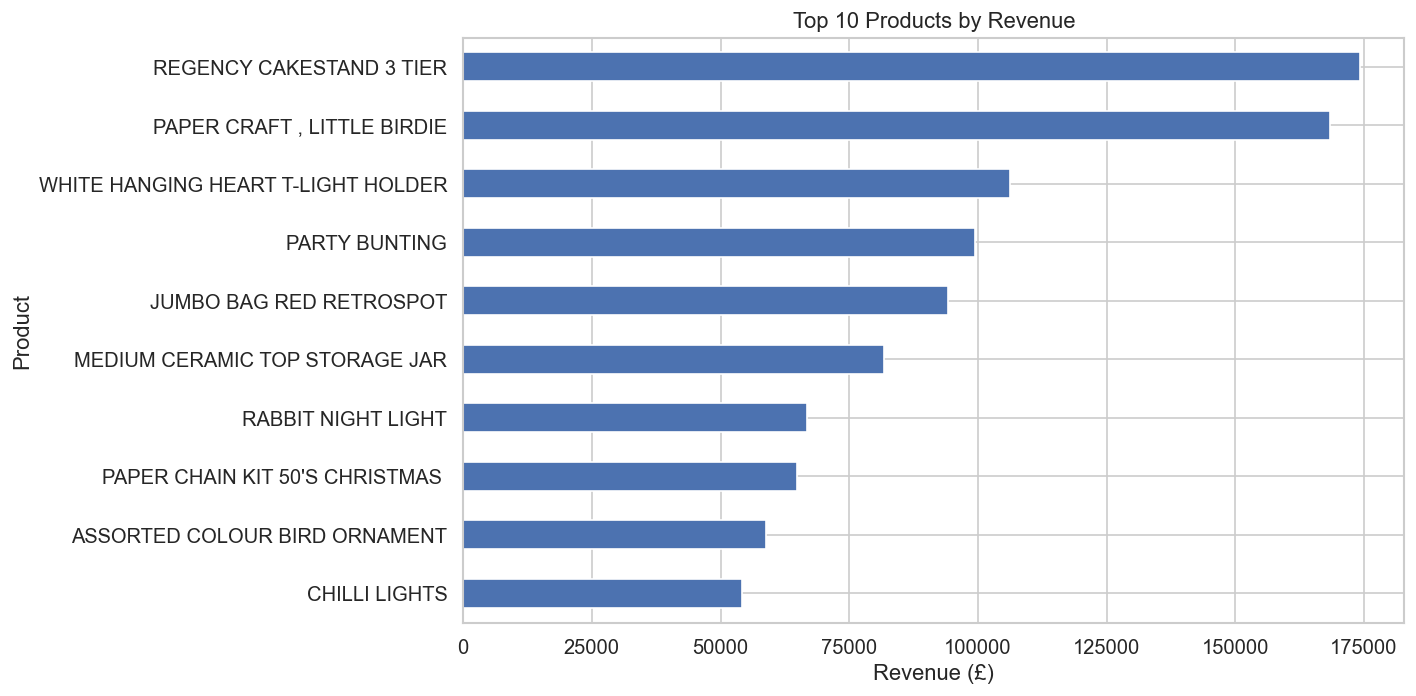

In [30]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [31]:
# ==========================================
# Revenue by Country
# ==========================================

country_sales = (
    df_clean.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

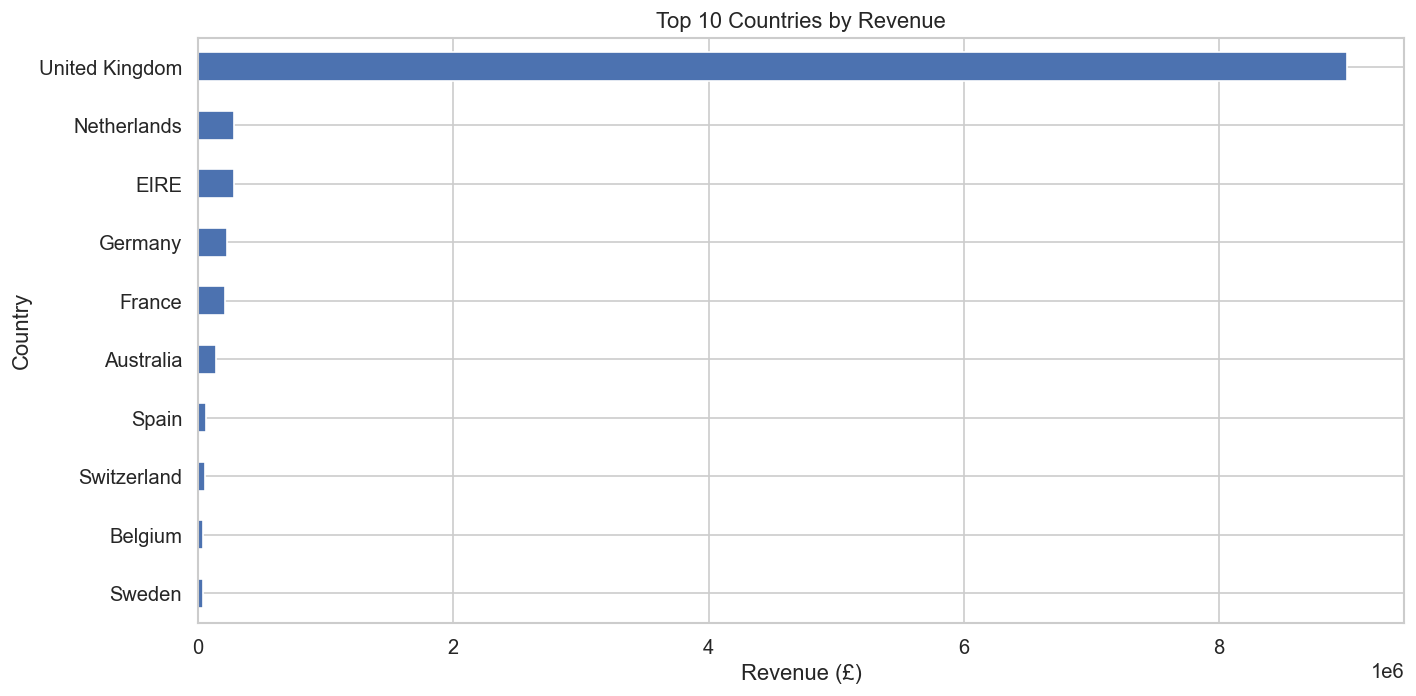

In [32]:
plt.figure(figsize=(12,6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue (£)")

plt.tight_layout()

plt.show()

In [33]:
# ==========================================
# Top 10 Products by Quantity Sold
# ==========================================

non_product_items = ["DOTCOM POSTAGE", "POSTAGE", "Manual"]

top_quantity = (
    df_clean[~df_clean["Description"].isin(non_product_items)]
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

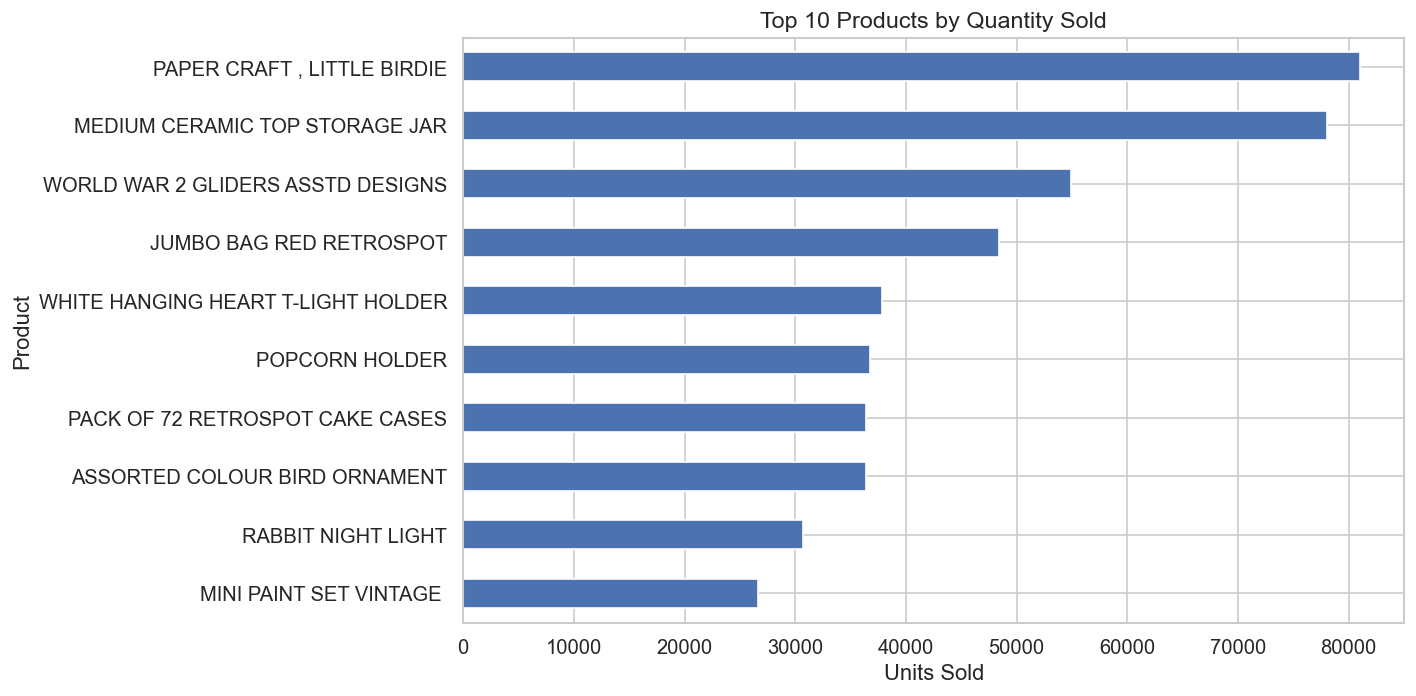

In [34]:
plt.figure(figsize=(12,6))

top_quantity.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold", fontsize=14)

plt.xlabel("Units Sold")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [35]:
# Revenue by Day of Week
day_sales = (
    df_clean.groupby("DayOfWeek")["TotalSales"]
    .sum()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = day_sales.reindex(day_order)

In [36]:
# ==========================================
# Top 10 Customers by Revenue
# ==========================================

top_customers = (
    df_clean[df_clean["CustomerID"].notna()]
    .groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.to_frame(name="Revenue")

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


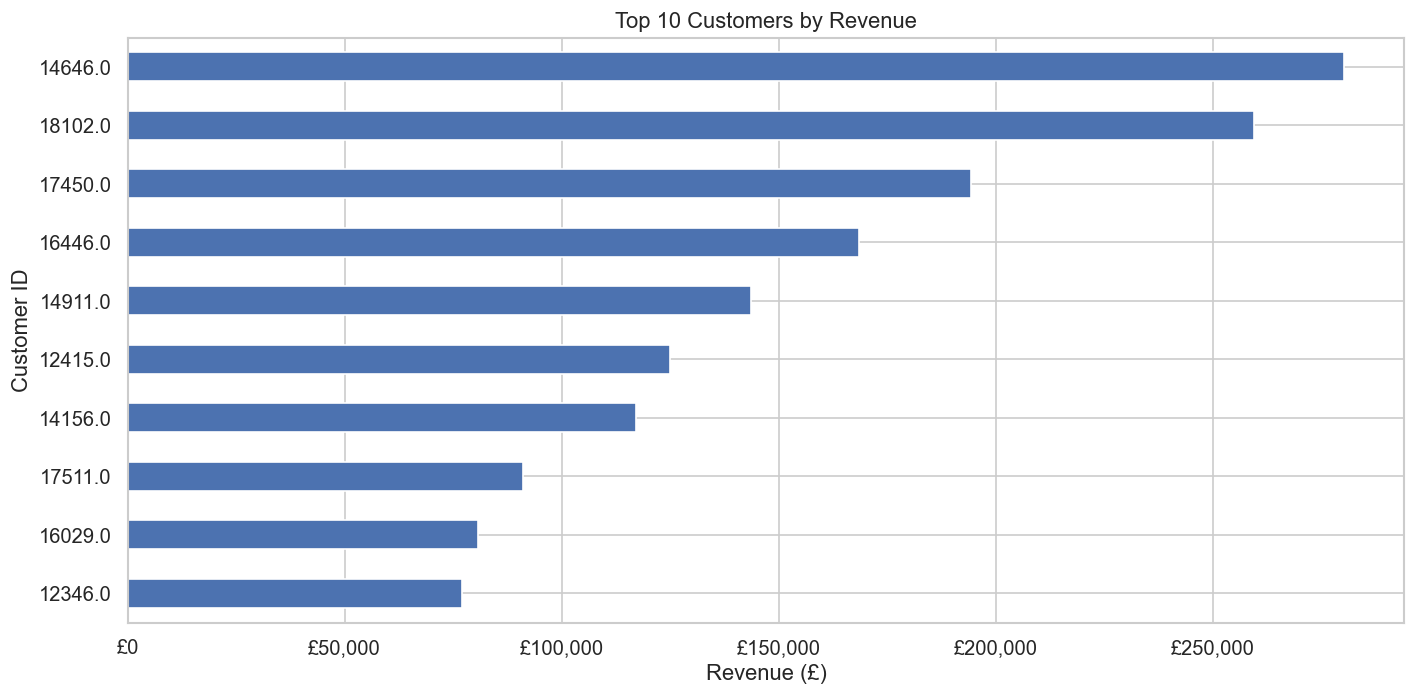

In [37]:
plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Revenue (£)")

plt.ylabel("Customer ID")

ax = plt.gca()
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

plt.tight_layout()
plt.show()

In [38]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Countries",
        "Products"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"£{average_order_value:,.2f}",
        countries,
        unique_products
    ]
})

summary

,Metric,Value
0,Total Revenue,"£10,642,110.80"
1,Total Orders,"19,960"
2,Total Customers,"4,338"
3,Average Order Value,£533.17
4,Countries,38
5,Products,3922


# Business Insights

Based on the exploratory analysis, the following insights were identified:

- Revenue peaks during the holiday season, with November generating the highest sales.
- The United Kingdom contributes the majority of revenue, while the Netherlands, Germany, France, and Ireland are the strongest international markets.
- A small number of products generate a large share of total revenue.
- Most orders are relatively small, while a limited number of high-value transactions increase the average order value.

# RFM Customer Segmentation

RFM (Recency, Frequency, Monetary) is a customer segmentation technique used to identify customer value and purchasing behavior.

- **Recency**: How recently the customer made a purchase.
- **Frequency**: How often the customer purchases.
- **Monetary**: How much the customer spends.

Customers are assigned scores based on these three metrics and grouped into meaningful business segments.

In [39]:
# ==========================================
# Build RFM Table
# ==========================================

rfm_df = df_clean[df_clean["CustomerID"].notna()].copy()

snapshot_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    rfm_df.groupby("CustomerID")
    .agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "TotalSales": "sum"
    })
)

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [40]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


In [41]:
# ==========================================
# RFM Scores
# ==========================================

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [42]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [43]:
# ==========================================
# Customer Segmentation
# ==========================================

def segment_customer(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 4:
        return "Potential Loyalists"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 4:
        return "At Risk"

    else:
        return "Others"


rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Others
12347.0,2,7,4310.00,5,5,5,555,Champions
12348.0,75,4,1797.24,2,4,4,244,At Risk
12349.0,19,1,1757.55,4,1,4,414,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,Others


In [44]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        CustomerCount=("Segment", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean")
    )
    .round(2)
    .sort_values("CustomerCount", ascending=False)
)

segment_summary

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary
Segment,,,,
Others,1784,174.57,1.36,586.24
Champions,1139,13.31,9.99,5191.77
Loyal Customers,821,38.04,3.64,1645.66
Potential Loyalists,319,18.52,1.24,455.23
At Risk,275,137.08,4.89,1569.60


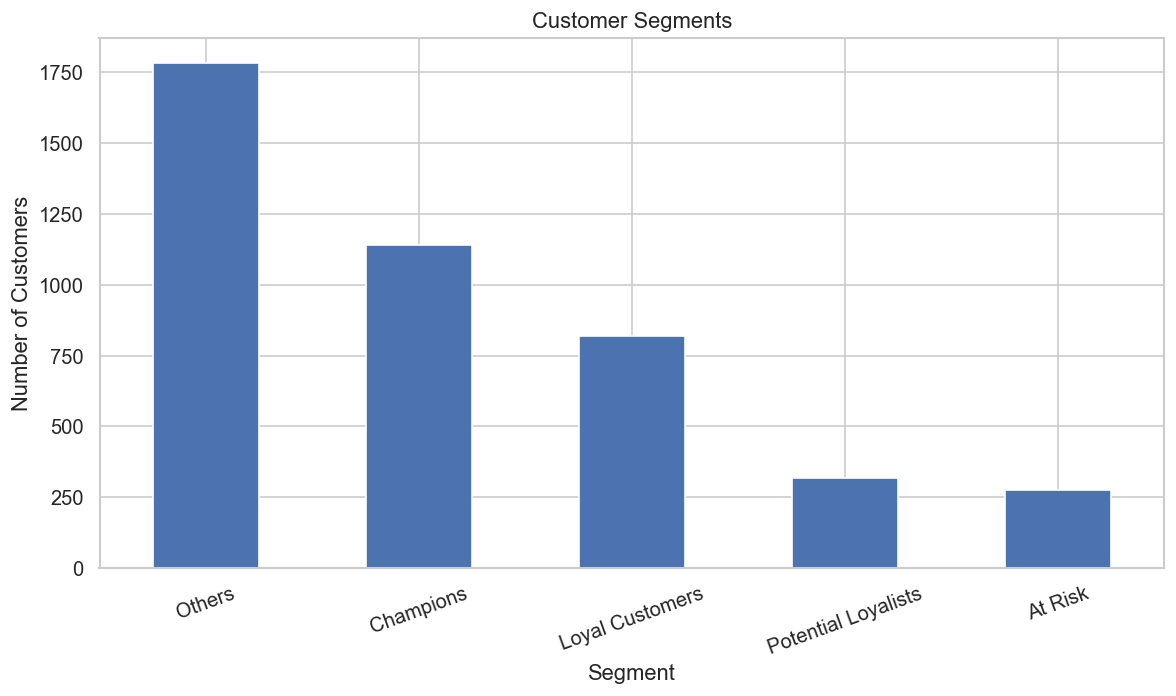

In [45]:
plt.figure(figsize=(10,6))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [46]:
rfm_segment = rfm.reset_index()[["CustomerID", "Segment"]]

segment_sales = (
    df_clean.merge(
        rfm_segment,
        on="CustomerID",
        how="left"
    )
)

In [47]:
segment_revenue = (
    segment_sales.groupby("Segment")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Champions              5913422.081
Loyal Customers        1351084.300
Others                 1045843.503
At Risk                 431639.270
Potential Loyalists     145219.740
Name: TotalSales, dtype: float64

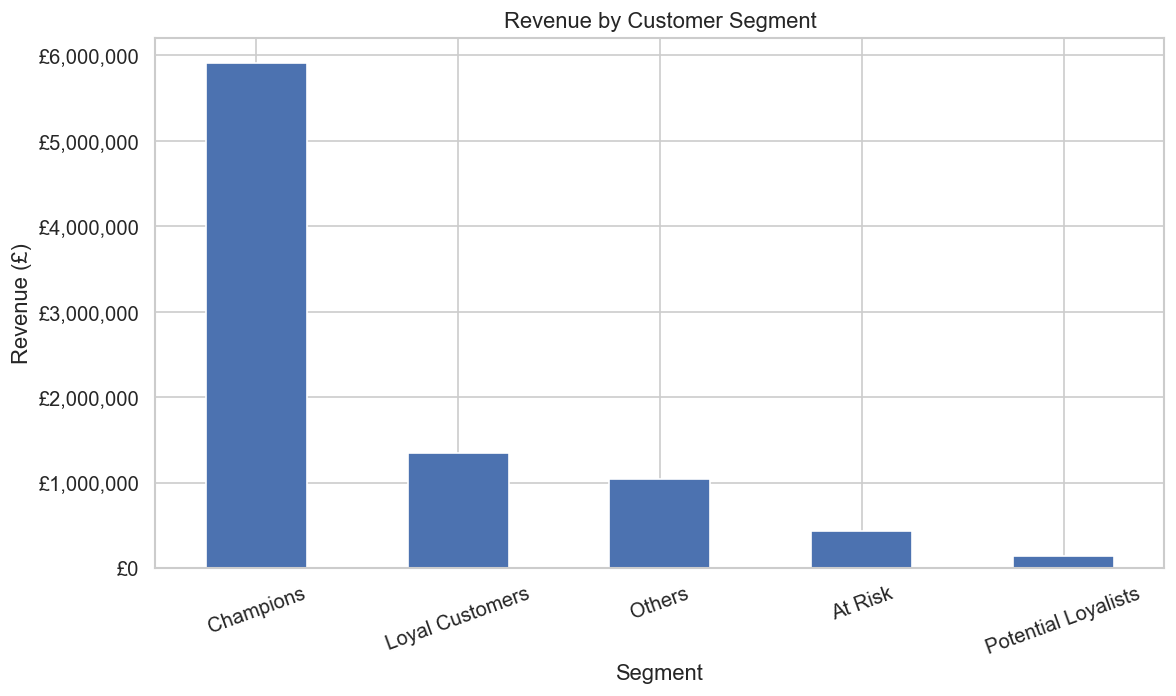

In [48]:
plt.figure(figsize=(10,6))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")

plt.ylabel("Revenue (£)")

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# RFM Analysis Insights

The RFM analysis provides a better understanding of customer behavior.

Key observations:

- Champions are the most valuable customers because they purchase frequently and recently.
- Loyal Customers contribute consistently to revenue and should be retained through loyalty programs.
- Potential Loyalists have strong potential to become long-term customers.
- At Risk customers were previously active but have not purchased recently.
- Other customers represent occasional buyers with lower engagement.

# Export RFM Segments

In [49]:
rfm.to_csv("../DataSet/rfm/rfm_segments.csv", index=True)

print(f"Saved: rfm_segments.csv  ({len(rfm):,} customers)")

Saved: rfm_segments.csv  (4,338 customers)


##  Export Cleaned Data

In [50]:
df_clean.to_csv("../DataSet/cleaned_data.csv", index=False)
print(f"Saved: cleaned_data.csv ({len(df_clean):,} rows)")

Saved: cleaned_data.csv (524,878 rows)
